## Simple Linear Regression

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
%matplotlib inline


In [2]:
df=pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [3]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


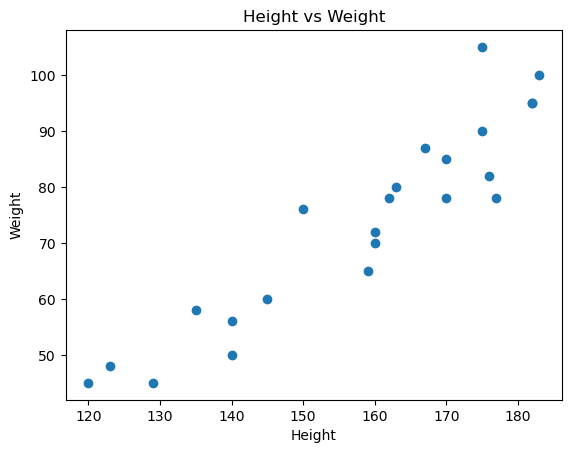

In [4]:
## scatter plot
plt.scatter(df['Height'],df['Weight'])
plt.xlabel('Height')    
plt.ylabel('Weight')
plt.title('Height vs Weight')
plt.show()

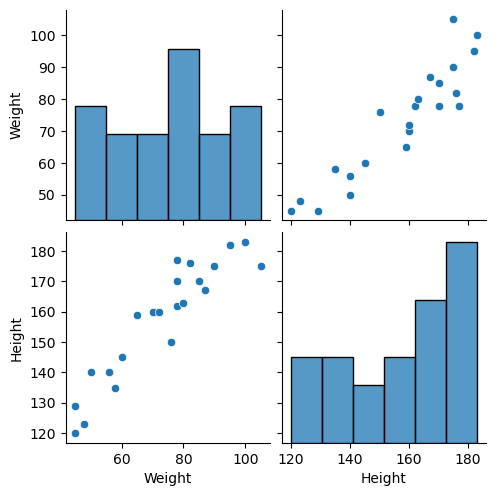

In [5]:
  ## seaborn for visualization
import seaborn as sns
sns.pairplot(df)

In [11]:
X_series=df['Weight'] ## independent features should be in 2D array or dataframe
type(X_series)
np.array(X_series).shape

(23,)

In [14]:
## divide features into independent and dependent features
X=df[['Weight']] ## independent features should be in 2D array or dataframe
# np.array(X).shape
# type(X)
# X.head()
y=df['Height'] ## dependent features can be in 1D array or series
# np.array(y).shape

In [15]:
## Train Test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [16]:
X_train

,Weight
1,58
13,100
5,78
2,48
11,95
20,45
3,60
4,70
18,76
16,50


In [17]:
X_test

,Weight
15,78
9,78
0,45
8,95
17,65
12,105


In [18]:
y_train

1     135
13    183
5     162
2     123
11    182
20    129
3     145
4     160
18    150
16    140
21    140
22    160
7     175
10    176
14    170
19    167
6     163
Name: Height, dtype: int64

In [19]:
y_test

15    177
9     170
0     120
8     182
17    159
12    175
Name: Height, dtype: int64

In [21]:
## standardize the data
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train) 
X_test_scaled=scaler.transform(X_test)
X_train_scaled
X_test_scaled


array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [22]:
## train the model
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train_scaled,y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)

Coefficient: [17.2982057]
Intercept: 156.47058823529412


Text(0.5, 1.0, 'Height vs Weight with Regression Line')

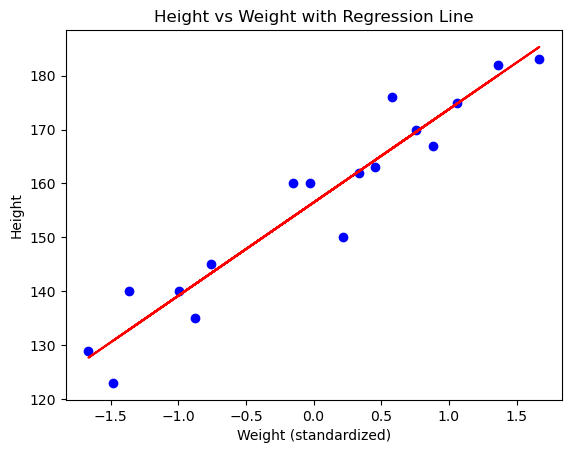

In [27]:
## plotting the regression line
plt.scatter(X_train_scaled,y_train,color='blue',label='Training data')
plt.plot(X_train_scaled,model.predict(X_train_scaled),color='red',label='Regression line')
plt.xlabel('Weight (standardized)')
plt.ylabel('Height')
plt.title('Height vs Weight with Regression Line')


## Prediction of Test Data

predicted height output= intercept+coef_(weight)

y_pred_test= 156.470+17.29(X_test)

In [28]:
## prediction on test data
y_pred=model.predict(X_test_scaled)
y_pred

array([162.26499721, 162.26499721, 127.68347133, 180.07972266,
       148.64197186, 190.55897293])

In [29]:
## Performance evaluation
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
r2_adj=1-(1-r2)*(len(y_test)-1)/(len(y_test)-X_test_scaled.shape[1]-1)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)
print("Adjusted R-squared:", r2_adj)    

Mean Squared Error: 114.84069295228699
Mean Absolute Error: 9.665125886795005
Root Mean Squared Error: 10.716374991212605
R-squared: 0.7360826717981276
Adjusted R-squared: 0.6701033397476595


In [30]:
## OLS method Linear regression using statsmodels
import statsmodels.api as sm



In [32]:
model_OLS=sm.OLS(y_train,X_train_scaled).fit()

In [33]:
predictions_OLS=model_OLS.predict(X_test_scaled)
print(predictions_OLS)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [34]:
print(model_OLS.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Thu, 30 Apr 2026   Prob (F-statistic):                       0.664
Time:                        11:10:18   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [35]:
## prediction for new data
model.predict(scaler.transform([[72]]))

e:\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])